In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from itertools import combinations

from core.complexes import compute_boundary_matrices, get_C_from_B, get_K_from_B
from core.dynamics import all_partitions
from core.rings import find_what_works_ring

All functions needed for this notebook

In [2]:
# Ring only

def ring_theta_dynamics(t, theta):
    theta = np.asarray(theta)
    return np.roll(np.sin(theta), -1) - 2*np.sin(theta) + np.roll(np.sin(theta), 1)

def theta_star_from_ring_root(zeta_minus, S_plus, S_minus, n_edges=6):
    zeta = float(np.atleast_1d(zeta_minus)[0])
    psi = np.full(n_edges, zeta)

    theta = np.zeros(n_edges)
    theta[S_plus] = np.arcsin(psi[S_plus])
    theta[S_minus] = np.pi - np.arcsin(psi[S_minus])

    return theta

def simulate_theta(theta_star, tmax=40, npts=2000, noise=1e-2, seed=0, preserve_sum=True):
    rng = np.random.default_rng(seed)
    eta = noise * rng.standard_normal(len(theta_star))

    if preserve_sum:
        eta = eta - np.mean(eta) # preserve total circulation / winding numbers

    theta0 = theta_star + eta

    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(ring_theta_dynamics, (0, tmax), theta0, t_eval=t_eval, rtol=1e-9, atol=1e-11, method="RK45")
    return sol

def plot_ring_timeseries_branches(sims, theta_stars, save_path="Fig3_timeseries.pdf"):
    """
    Plot three stacked time-series panels for the three stable ring branches.

    Parameters
    ----------
    sims : list
        List of solve_ivp solution objects, one per branch.
    theta_stars : list[np.ndarray]
        Corresponding stationary twisted states.
    save_path : str
        Output path.
    figsize : tuple
        Figure size chosen to visually match the branch-diagram panel.
    """
    fig, axes = plt.subplots(3, 1, figsize=(7, 6.4), sharex=True)

    # six consistent edge colors
    edge_colors = plt.cm.viridis(np.linspace(0.12, 0.88, 6))
    panel_labels = ["b", "c", "d"]
    horizontal_lines = [np.pi/3, 0, -np.pi/3]

    for ax, sol, theta_star, plabel, hl in zip(axes, sims, theta_stars, panel_labels, horizontal_lines):
        z = int(round(np.sum(theta_star) / (2 * np.pi)))

        for j in range(sol.y.shape[0]):
            ax.plot(sol.t, sol.y[j], lw=1.6, color=edge_colors[j], label=rf"$i={j+1}$" if ax is axes[0] else None)

        ax.axhline(hl, ls="--", lw=1.0, color="0.5", alpha=0.9)

        ref_label = {-1: r"$-\pi/3$",0: r"$0$", 1: r"$\pi/3$"}.get(z, rf"${theta_star[0]:.2f}$")

        ax.annotate(ref_label, xy=(0.985, theta_star[0]), xycoords=("axes fraction", "data"), xytext=(-2, -4), textcoords="offset points",
                    ha="right", va="top", fontsize=14, color="0.35")

        ax.set_ylabel(r"$\theta_i^{[-]}(t)$", fontsize=16)
        ax.tick_params(axis="both", labelsize=14)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

        ax.text(-0.15, 0.92, plabel, transform=ax.transAxes, ha="left", va="bottom", fontsize=16, weight="bold", clip_on=False)
        ax.text(0.98, 0.92, rf"$z^{{[-]}}={z}$", transform=ax.transAxes, ha="right", va="top", fontsize=14)


    axes[0].legend(loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=6, frameon=False, fontsize=14, handlelength=1.2,
                   columnspacing=0.8, handletextpad=0.35, borderaxespad=0.2)

    axes[-1].set_xlabel(r"$t$", fontsize=16)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [7]:
# Ring and cube

def wrap_to_pi(x):
    x = np.asarray(x, dtype=float)
    return (x + np.pi) % (2 * np.pi) - np.pi

def projected_angles_from_windings(z_minus, z_plus, N0, N2):
    """
    All-normal projected angles for the stable branch:
        theta^- = 2 pi z^- / N0
        theta^+ = 2 pi z^+ / N2
    """
    theta_minus = (2 * np.pi * z_minus / N0) * np.ones(N0)
    theta_plus  = (2 * np.pi * z_plus  / N2) * np.ones(N2)
    return theta_minus, theta_plus

def sparse_integer_shifts(n, total):
    """
    Integer shift vectors m with entries in {-1,0,1} and sum(m)=total,
    using the minimal number of nonzero entries.
    Good for the small |z| used in the paper examples.
    """
    if total == 0:
        return [np.zeros(n, dtype=int)]

    sign = 1 if total > 0 else -1
    k = abs(total)

    out = []
    for idx in combinations(range(n), k):
        m = np.zeros(n, dtype=int)
        m[list(idx)] = sign
        out.append(m)
    return out

def edge_dynamics_n1(t, theta, B1, B2):
    theta = np.asarray(theta, dtype=float)
    return -B1.T @ np.sin(B1 @ theta) - B2 @ np.sin(B2.T @ theta)


# Reconstruct edge equilibria from winding numbers
def lift_equilibrium_from_windings(B1, B2, z_minus, z_plus, linear_tol=1e-10, dyn_tol=1e-9):
    """
    Find an edge-phase equilibrium theta such that
        B1 theta   = theta^- - 2 pi m^-
        B2^T theta = theta^+ - 2 pi m^+
    for some integer shift vectors m^-, m^+,
    and verify that theta is an equilibrium of the full edge ODE.

    Returns
    -------
    theta_star : ndarray
    info : dict
        contains chosen shifts and diagnostics
    """
    N0 = B1.shape[0]
    N2 = B2.shape[1]

    theta_minus, theta_plus = projected_angles_from_windings(z_minus, z_plus, N0, N2)
    A = np.vstack([B1, B2.T])

    minus_shifts = sparse_integer_shifts(N0, z_minus)
    plus_shifts = sparse_integer_shifts(N2, z_plus)

    best = None
    best_score = np.inf

    for m_minus in minus_shifts:
        rhs_minus = theta_minus - 2 * np.pi * m_minus

        for m_plus in plus_shifts:
            rhs_plus = theta_plus - 2 * np.pi * m_plus
            b = np.concatenate([rhs_minus, rhs_plus])

            theta_star, *_ = np.linalg.lstsq(A, b, rcond=None)
            theta_star = wrap_to_pi(theta_star)

            lin_res = np.linalg.norm(A @ theta_star - b)
            dyn_res = np.linalg.norm(edge_dynamics_n1(0.0, theta_star, B1, B2))

            score = lin_res + dyn_res
            if score < best_score:
                best_score = score
                best = (theta_star, m_minus, m_plus, lin_res, dyn_res)

    theta_star, m_minus, m_plus, lin_res, dyn_res = best

    if lin_res > linear_tol or dyn_res > dyn_tol:
        raise RuntimeError(
            f"No consistent lifted equilibrium found for "
            f"(z_minus,z_plus)=({z_minus},{z_plus}); "
            f"best linear residual={lin_res:.3e}, dynamics residual={dyn_res:.3e}"
        )

    info = {
        "z_minus": z_minus,
        "z_plus": z_plus,
        "m_minus": m_minus,
        "m_plus": m_plus,
        "linear_residual": lin_res,
        "dynamics_residual": dyn_res,
        "theta_minus": B1 @ theta_star,
        "theta_plus": B2.T @ theta_star,
        "psi_minus": np.sin(B1 @ theta_star),
        "psi_plus": np.sin(B2.T @ theta_star),
    }
    return theta_star, info

def simulate_edge_timeseries(theta_star, B1, B2, tmax=25, npts=2000, noise=1e-2, seed=0):
    rng = np.random.default_rng(seed)
    theta0 = theta_star + noise * rng.standard_normal(len(theta_star))

    t_eval = np.linspace(0, tmax, npts)
    sol = solve_ivp(lambda t, th: edge_dynamics_n1(t, th, B1, B2), (0, tmax), theta0, t_eval=t_eval, rtol=1e-9, atol=1e-11, method="RK45")
    return sol

def make_intro_timeseries_pair(B1, B2, branch1, branch2, tmax=25, npts=2000, noise=1e-2, seed1=1, seed2=2):
    """
    branch1, branch2 are tuples (z_minus, z_plus).
    Returns equilibria, diagnostics, and trajectories.
    """
    theta_star_1, info1 = lift_equilibrium_from_windings(B1, B2, *branch1)
    theta_star_2, info2 = lift_equilibrium_from_windings(B1, B2, *branch2)

    sol1 = simulate_edge_timeseries(theta_star_1, B1, B2, tmax=tmax, npts=npts, noise=noise, seed=seed1)
    sol2 = simulate_edge_timeseries(theta_star_2, B1, B2, tmax=tmax, npts=npts, noise=noise, seed=seed2)

    return {
        "theta_star_1": theta_star_1,
        "theta_star_2": theta_star_2,
        "info1": info1,
        "info2": info2,
        "sol1": sol1,
        "sol2": sol2,
    }

def plot_intro_edge_timeseries_stacked(data, save_path="Fig_example_timeseries.pdf", figsize=(5.6, 4.0), line_color="#003366"):
    """
    Plot two stacked edge-time-series panels, one trajectory per panel.
    Works for both ring and cube as long as `data` contains:
        sol1, sol2, info1, info2
    """
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, gridspec_kw={"hspace": 0})

    sol1, sol2 = data["sol1"], data["sol2"]
    info1, info2 = data["info1"], data["info2"]

    n_edges = sol1.y.shape[0]

    panels = [(axes[0], sol1, info1, "IC 1"), (axes[1], sol2, info2, "IC 2")]

    for ax, sol, info, ic_label in panels:
        for j in range(n_edges):
            ax.plot(sol.t, sol.y[j], color=line_color, lw=1.3)

        ax.set_ylabel(r"$\theta_{[j,k]}(t)$", fontsize=16)
        ax.tick_params(axis="both", labelsize=14)
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))


    axes[1].set_xlabel(r"$t$", fontsize=16)

    axes[0].tick_params(labelbottom=False)
    axes[1].tick_params(axis="x", pad=6)

    if np.min(sol.y) < -1.8:
        axes[1].set_ylim([-2.5, 2.5])

    plt.tight_layout()
    fig.subplots_adjust(hspace=0.02)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

Ring

In [4]:
# Choose a partition
S0_ring = [[1], [2], [3], [4], [5], [6]]
S1_ring = [[1,2], [2,3], [3,4], [4,5], [5,6], [6,1]]
S2_ring = [[1,2,3,4,5,6]]

S_ring = [S0_ring, S1_ring, S2_ring]

ring_partitions = all_partitions(len(S_ring[1]))
S_plus, S_minus = ring_partitions[0] # all-plus partition

# Boundary matrices, C-matrices, unit couplings
boundary_matrices_ring = compute_boundary_matrices(S_ring)

B1r, B2r = boundary_matrices_ring
C1r, C2r = get_C_from_B(B1r, B2r)
K1r, K2r = get_K_from_B(B1r, B2r)

# Find roots
roots_ring = find_what_works_ring(S_plus=S_plus, S_minus=S_minus, B1=B1r, K1=K1r, C1=C1r, z_range=range(-1, 5), verbose=False)

# Simulate dynamics from perturbed fixed points
all_results = []
all_xstars = []

omega = np.zeros(B1r.shape[1])

theta_stars = []
for root in roots_ring:
    z_plus, z_minus, zeta_plus, zeta_minus = root
    theta_star = theta_star_from_ring_root(zeta_minus, S_plus, S_minus, n_edges=6)
    theta_stars.append(theta_star)
    print(theta_star, " winding =", np.sum(theta_star)/(2*np.pi))

sims = []
for i, theta_star in enumerate(theta_stars):
    sol = simulate_theta(theta_star, tmax=20, npts=2500, noise=2e-2, seed=10+i, preserve_sum=True)
    sims.append(sol)

[1.04719755 1.04719755 1.04719755 1.04719755 1.04719755 1.04719755]  winding = 1.0000000000000002
[0. 0. 0. 0. 0. 0.]  winding = 0.0
[-1.04719755 -1.04719755 -1.04719755 -1.04719755 -1.04719755 -1.04719755]  winding = -0.9999999999999999


Figure 1 e

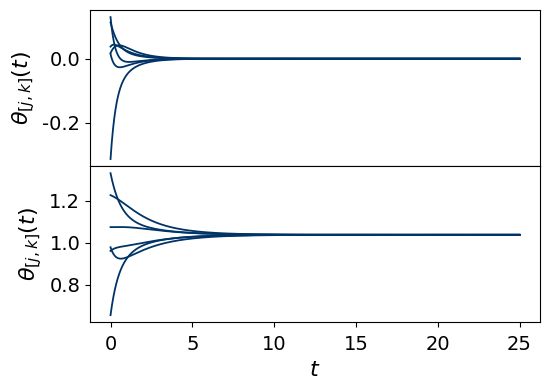

In [5]:
S_plus, S_minus = ring_partitions[0]
theta_star_ring_0 = theta_star_from_ring_root(zeta_minus=0.0, S_plus=S_plus, S_minus=S_minus, n_edges=6)

theta_star_ring_1 = theta_star_from_ring_root(zeta_minus=np.sqrt(3)/2, S_plus=S_plus, S_minus=S_minus, n_edges=6)

sol_ring_0 = simulate_theta(theta_star_ring_0, tmax=25, npts=2000, noise=0.20, seed=1, preserve_sum=True)

sol_ring_1 = simulate_theta(theta_star_ring_1, tmax=25, npts=2000, noise=0.20, seed=2, preserve_sum=True)

ring_data = {"sol1": sol_ring_0, "sol2": sol_ring_1, "info1": {"z_minus": 0, "z_plus": None}, "info2": {"z_minus": 1, "z_plus": None}}

plot_intro_edge_timeseries_stacked(ring_data, save_path="Fig_example_ring_timeseries.pdf")

Figure 3 b, c, d

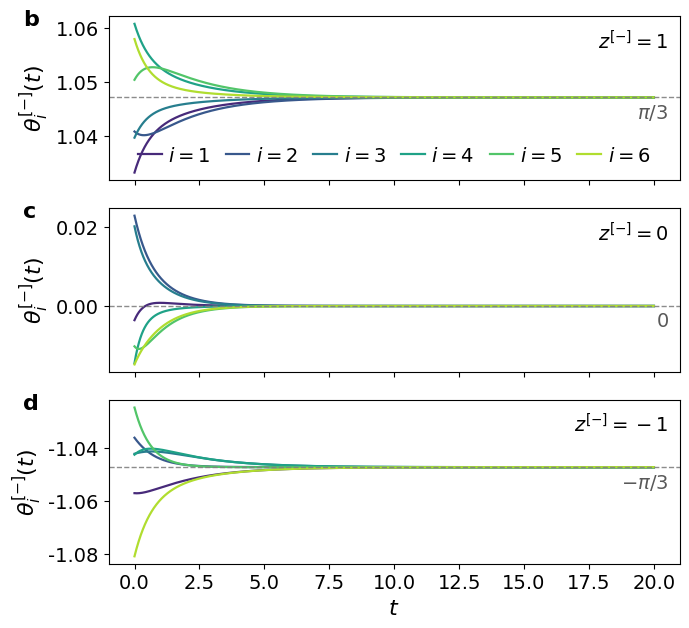

In [6]:
plot_ring_timeseries_branches(sims, theta_stars, save_path="Fig3_timeseries.pdf")

Cube: Fig 1, f

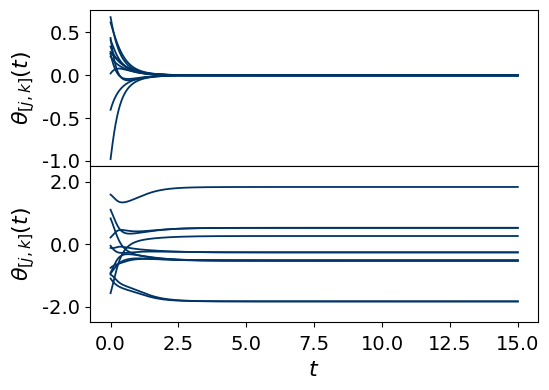

In [8]:
B1c = np.array([
    [-1,  0,  0, +1,  0,  0,  0,  0, -1,  0,  0,  0],
    [+1, -1,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0],
    [ 0, +1, -1,  0,  0,  0,  0,  0,  0,  0, -1,  0],
    [ 0,  0, +1, -1,  0,  0,  0,  0,  0,  0,  0, -1],
    [ 0,  0,  0,  0, -1,  0,  0, +1, +1,  0,  0,  0],
    [ 0,  0,  0,  0, +1, -1,  0,  0,  0, +1,  0,  0],
    [ 0,  0,  0,  0,  0, +1, -1,  0,  0,  0, +1,  0],
    [ 0,  0,  0,  0,  0,  0, +1, -1,  0,  0,  0, +1],
], dtype=int)

B2cT = np.array([
    [+1, +1, +1, +1,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0, +1, +1, +1, +1,  0,  0,  0,  0],
    [-1,  0,  0,  0, +1,  0,  0,  0, +1, -1,  0,  0],
    [ 0,  0, +1,  0,  0,  0, -1,  0,  0,  0, -1, +1],
    [ 0,  0,  0, +1,  0,  0,  0, -1, +1,  0,  0, -1],
    [ 0, -1,  0,  0,  0, +1,  0,  0,  0, +1, -1,  0],
], dtype=int)

B2c = B2cT.T

cube_data = make_intro_timeseries_pair(B1c, B2c, branch1=(0, 0), branch2=(1, 0), tmax=15, npts=2000, noise=0.75, seed1=1, seed2=2)

plot_intro_edge_timeseries_stacked(cube_data, save_path="Fig_example_cube_timeseries.pdf")